# AutoCharterModel — Evaluación e Inferencia

Notebook para evaluar el modelo entrenado (`checkpoints/run1/best`) sobre un **subset del dataset** completo, y para correr inferencia muestra a muestra.

**Secciones:**
1. Imports y configuración
2. Cargar modelo
3. Cargar y subsetear el dataset
4. Evaluación cuantitativa (loss, token accuracy, perplexity, note F1, beat accuracy)
5. Desglose por instrumento y dificultad
6. Inferencia individual
7. Visualización de resultados

## 1 · Imports y configuración

In [1]:
import sys, json, random
from pathlib import Path
from collections import defaultdict

import torch
import numpy as np

# ── Paths ──────────────────────────────────────────────────────────────────────
REPO_ROOT      = Path("/s/mlopezs8/CloneCharter")
CHECKPOINT_DIR = REPO_ROOT / "checkpoints/run1/best"
DATASET_DIR    = REPO_ROOT / "dataset"

sys.path.insert(0, str(REPO_ROOT / "src"))

# ── Config ────────────────────────────────────────────────────────────────────
EVAL_SUBSET_SIZE = 200        # muestras aleatorias del dataset completo
BATCH_SIZE       = 8
SEED             = 42
MAX_TOKENS       = 8192
MAX_BEATS        = 1024

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Checkpoint: {CHECKPOINT_DIR}")
print(f"Dataset:    {DATASET_DIR}")

Device: cuda
Checkpoint: /s/mlopezs8/CloneCharter/checkpoints/run1/best
Dataset:    /s/mlopezs8/CloneCharter/dataset


## 2 · Cargar el modelo

In [2]:
from auto_charter.model.charter_model import AutoCharterModel

model = AutoCharterModel.from_pretrained(CHECKPOINT_DIR)
model = model.to(DEVICE)
model.eval()

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Modelo cargado: {n_params:,} parámetros")
print(f"  vocab_size : {model.config.vocab_size}")
print(f"  d_model    : {model.config.d_model}")
print(f"  enc_layers : {model.config.n_enc_layers}")
print(f"  dec_layers : {model.config.n_dec_layers}")

# Leer trainer_state para referencia
state_path = CHECKPOINT_DIR / "trainer_state.json"
if state_path.exists():
    state = json.loads(state_path.read_text())
    print(f"\nMejor val_loss registrado : {state['best_val_loss']:.4f}")
    print(f"Global step               : {state['global_step']:,}")

Modelo cargado: 8,038,017 parámetros
  vocab_size : 187
  d_model    : 256
  enc_layers : 4
  dec_layers : 4

Mejor val_loss registrado : 1.0534
Global step               : 145,188


## 3 · Cargar y subsetear el dataset

Se carga el dataset completo desde disco y se seleccionan `EVAL_SUBSET_SIZE` muestras aleatorias estratificadas por instrumento para la evaluación.

In [3]:
import datasets as hf_datasets
from torch.utils.data import DataLoader, Subset
from auto_charter.training.dataset import AutoCharterDataset
from auto_charter.training.collator import AutoCharterTrainCollator

# ── Cargar dataset Arrow completo ─────────────────────────────────────────────
raw_ds = hf_datasets.load_from_disk(str(DATASET_DIR))
print(f"Dataset cargado: {raw_ds}")

# Aplanar si es DatasetDict
if isinstance(raw_ds, hf_datasets.DatasetDict):
    hf_split = raw_ds["train"]
else:
    hf_split = raw_ds

print(f"Split usado: {len(hf_split):,} filas totales")

# ── Subset estratificado por instrumento (acceso vectorial Arrow, sin loop) ───
random.seed(SEED)
_INSTR_NAMES = {0: "guitar", 1: "bass", 2: "drums"}
_INSTR_TO_ID = {"guitar": 0, "bass": 1, "drums": 2}

# Leer toda la columna "instrument" de una sola vez — O(N) en Arrow, muy rápido
instruments = hf_split["instrument"]   # list[str], sin deserializar el resto

by_instr: dict[int, list[int]] = defaultdict(list)
for i, instr in enumerate(instruments):
    by_instr[_INSTR_TO_ID.get(instr, 0)].append(i)

n_per_instr = EVAL_SUBSET_SIZE // max(len(by_instr), 1)
subset_indices = []
for instr_id, indices in sorted(by_instr.items()):
    sampled = random.sample(indices, min(n_per_instr, len(indices)))
    subset_indices.extend(sampled)
    print(f"  {_INSTR_NAMES.get(instr_id)}: {len(sampled)} / {len(indices)} muestras")

random.shuffle(subset_indices)

# Seleccionar el subset en Arrow antes de crear AutoCharterDataset
# → solo se carga en RAM el subset, no el dataset completo
hf_subset = hf_split.select(subset_indices)
eval_dataset = AutoCharterDataset(hf_subset, max_tokens=MAX_TOKENS, max_beats=MAX_BEATS)
print(f"\nSubset final: {len(eval_dataset)} muestras")

Loading dataset from disk:   0%|          | 0/1025 [00:00<?, ?it/s]

Dataset cargado: DatasetDict({
    train: Dataset({
        features: ['song_id', 'instrument', 'source_format', 'tokens', 'num_tokens', 'num_beats', 'mert_embeddings', 'logmel_frames', 'beat_times_s', 'beat_durations_s', 'bpm_at_beat', 'time_sig_num_at_beat', 'time_sig_den_at_beat', 'song_name', 'artist', 'genre', 'charter', 'year', 'song_length_ms', 'difficulty', 'resolution', 'has_star_power', 'has_solo', 'has_dedicated_stem', 'num_notes', 'notes_per_beat_mean', 'chord_ratio', 'sustain_mean_ticks', 'bpm_mean', 'bpm_std'],
        num_rows: 43665
    })
})
Split usado: 43,665 filas totales
  guitar: 66 / 28775 muestras
  bass: 66 / 5915 muestras
  drums: 66 / 8975 muestras
AutoCharterDataset: 198 rows

Subset final: 198 muestras


## 4 · Evaluación cuantitativa

Corremos el modelo en modo `eval()` sobre el subset y calculamos:
- **Loss** (cross-entropy con label smoothing desactivado para evaluación limpia)
- **Token accuracy** — fracción de tokens no-PAD predichos correctamente
- **Perplexity** — exp(CE loss)
- **Note F1 / Beat accuracy** — métricas a nivel de nota (requiere greedy decoding)

In [4]:
import torch.nn.functional as F
from tqdm.auto import tqdm
from auto_charter.training import metrics as M
from auto_charter.vocab.tokens import Vocab

_INSTR_NAMES  = {0: "guitar", 1: "bass", 2: "drums"}
_DIFF_NAMES   = {0: "easy", 1: "medium", 2: "hard", 3: "expert",
                 4: "expert+", 5: "expert++", 6: "expert+++"}

collator = AutoCharterTrainCollator(
    max_tokens=MAX_TOKENS, max_beats=MAX_BEATS, mert_dim=model.config.mert_dim
)
eval_loader = DataLoader(
    eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collator,
    num_workers=0,
)

# Acumuladores globales
global_acc: dict[str, dict] = defaultdict(lambda: {
    "loss": 0.0, "tok_acc": 0.0, "ppl": 0.0,
    "note_f1": 0.0, "beat_acc": 0.0, "n": 0
})

all_results: list[dict] = []   # guardamos por muestra para análisis posterior

model.eval()
with torch.no_grad():
    for batch in tqdm(eval_loader, desc="Evaluando"):
        dev = {k: v.to(DEVICE) if hasattr(v, "to") else v for k, v in batch.items()}

        output = model(
            mert_embeddings  = dev["mert_embeddings"],
            logmel_frames    = dev["logmel_frames"],
            bpm_at_beat      = dev["bpm_at_beat"],
            time_sig_num     = dev["time_sig_num"],
            time_sig_den     = dev["time_sig_den"],
            beat_duration_s  = dev["beat_duration_s"],
            beat_padding_mask= dev["beat_attention_mask"],
            input_ids        = dev["input_ids"],
            beat_ids         = dev["beat_ids"],
            instrument_ids   = dev["instrument_ids"],
            difficulty_ids   = dev["difficulty_ids"],
            labels           = dev["labels"],
        )

        loss_val = output.loss.item()
        tok_acc  = M.token_accuracy(output.logits.float(), dev["labels"])
        ppl      = M.perplexity(output.logits.float(), dev["labels"])

        # Greedy decode para note_f1 y beat_accuracy
        greedy_ids = output.logits.argmax(dim=-1).cpu().tolist()   # [B, T]
        target_ids = dev["labels"].cpu().tolist()                  # [B, T]

        f1_metrics = M.note_f1(greedy_ids, target_ids)
        beat_acc   = M.beat_accuracy(greedy_ids, target_ids)

        B = batch["instrument_ids"].shape[0]
        for i in range(B):
            instr_id   = batch["instrument_ids"][i].item()
            diff_id    = batch["difficulty_ids"][i].item()
            instr_name = _INSTR_NAMES.get(instr_id, str(instr_id))
            diff_name  = _DIFF_NAMES.get(diff_id, str(diff_id))

            for key in (instr_name, f"diff_{diff_name}", "__total__"):
                d = global_acc[key]
                d["loss"]     += loss_val
                d["tok_acc"]  += tok_acc
                d["ppl"]      += ppl
                d["note_f1"]  += f1_metrics["note_f1"]
                d["beat_acc"] += beat_acc
                d["n"]        += 1

            all_results.append({
                "instrument": instr_name,
                "difficulty": diff_name,
                "loss": loss_val,
                "tok_acc": tok_acc,
                "perplexity": ppl,
                "note_f1": f1_metrics["note_f1"],
                "beat_accuracy": beat_acc,
            })

print("✓ Evaluación completada")

def avg(d: dict, key: str) -> float:
    return d[key] / max(d["n"], 1)

tot = global_acc["__total__"]
print(f"\n{'Métrica':>20} | {'Valor':>10}")
print("-" * 35)
print(f"{'Loss':>20} | {avg(tot, 'loss'):10.4f}")
print(f"{'Token Accuracy':>20} | {avg(tot, 'tok_acc'):10.4f}")
print(f"{'Perplexity':>20} | {avg(tot, 'ppl'):10.2f}")
print(f"{'Note F1':>20} | {avg(tot, 'note_f1'):10.4f}")
print(f"{'Beat Accuracy':>20} | {avg(tot, 'beat_acc'):10.4f}")

Evaluando:   0%|          | 0/25 [00:00<?, ?it/s]

✓ Evaluación completada

             Métrica |      Valor
-----------------------------------
                Loss |     1.0371
      Token Accuracy |     0.9341
          Perplexity |       1.35
             Note F1 |     0.1452
       Beat Accuracy |     0.6842


## 5 · Desglose por instrumento y dificultad

In [5]:
def print_table(title: str, keys: list[str], key_label: str = "Grupo"):
    header = f"{'':>14} | {'Loss':>8} | {'TokAcc':>7} | {'PPL':>8} | {'NoteF1':>7} | {'BeatAcc':>8} | {'N':>5}"
    print(f"\n{title}")
    print(header)
    print("-" * len(header))
    for k in keys:
        if k not in global_acc:
            continue
        d = global_acc[k]
        n = d["n"]
        print(
            f"{k:>14} | {avg(d,'loss'):8.4f} | {avg(d,'tok_acc'):7.4f} | "
            f"{avg(d,'ppl'):8.2f} | {avg(d,'note_f1'):7.4f} | "
            f"{avg(d,'beat_acc'):8.4f} | {n:>5}"
        )

# Por instrumento
print_table("Por instrumento", ["guitar", "bass", "drums"])

# Por dificultad
diff_keys = [f"diff_{v}" for v in _DIFF_NAMES.values()]
print_table("Por dificultad", diff_keys)


Por instrumento
               |     Loss |  TokAcc |      PPL |  NoteF1 |  BeatAcc |     N
---------------------------------------------------------------------------
        guitar |   1.0491 |  0.9295 |     1.37 |  0.1537 |   0.6611 |    66
          bass |   1.0275 |  0.9377 |     1.34 |  0.1400 |   0.6982 |    66
         drums |   1.0348 |  0.9351 |     1.35 |  0.1419 |   0.6933 |    66

Por dificultad
               |     Loss |  TokAcc |      PPL |  NoteF1 |  BeatAcc |     N
---------------------------------------------------------------------------
     diff_easy |   1.0102 |  0.9442 |     1.31 |  0.1460 |   0.6905 |    17
   diff_medium |   1.0401 |  0.9326 |     1.36 |  0.1486 |   0.6948 |    22
     diff_hard |   1.0371 |  0.9340 |     1.35 |  0.1550 |   0.7237 |    44
   diff_expert |   1.0357 |  0.9353 |     1.35 |  0.1334 |   0.6921 |    54
  diff_expert+ |   1.0396 |  0.9327 |     1.36 |  0.1445 |   0.6455 |    34
 diff_expert++ |   1.0382 |  0.9341 |     1.35 |  0.154

## 6 · Inferencia individual

Tomamos una muestra del subset, la pasamos por `model.generate()` en modo autoregresivo y mostramos los tokens generados vs. los tokens de referencia.

In [6]:
# ── Parámetros de inferencia (ajustar libremente) ────────────────────────────
SAMPLE_IDX     = 0        # índice dentro de eval_dataset
TEMPERATURE    = 1.0
TOP_K          = 0        # 0 = desactivado
TOP_P          = 1.0      # 1.0 = desactivado
MAX_NEW_TOKENS = 512      # limitar para velocidad; usar model.config.max_new_tokens para completo

# ── Preparar muestra ──────────────────────────────────────────────────────────
sample_row   = eval_dataset[SAMPLE_IDX]
sample_batch = collator([sample_row])

def _t(key):
    return sample_batch[key].to(DEVICE)

instr_id = sample_batch["instrument_ids"][0].item()
diff_id  = sample_batch["difficulty_ids"][0].item()
print(f"Instrumento : {_INSTR_NAMES.get(instr_id, instr_id)}")
print(f"Dificultad  : {_DIFF_NAMES.get(diff_id, diff_id)}")
print(f"Tokens ref  : {len(sample_batch['labels'][0])}")

# ── Generar ───────────────────────────────────────────────────────────────────
model.eval()
generated_tokens = model.generate(
    mert_embeddings   = _t("mert_embeddings"),
    logmel_frames     = _t("logmel_frames"),
    bpm_at_beat       = _t("bpm_at_beat"),
    time_sig_num      = _t("time_sig_num"),
    time_sig_den      = _t("time_sig_den"),
    beat_duration_s   = _t("beat_duration_s"),
    beat_padding_mask = _t("beat_attention_mask"),
    instrument_id     = instr_id,
    difficulty_id     = diff_id,
    max_new_tokens    = MAX_NEW_TOKENS,
    temperature       = TEMPERATURE,
    top_k             = TOP_K,
    top_p             = TOP_P,
)

ref_tokens = [t for t in sample_batch["labels"][0].tolist() if t != Vocab.PAD]

print(f"\nTokens generados : {len(generated_tokens)}")
print(f"Tokens referencia: {len(ref_tokens)}")
print(f"\nGenerados (primeros 40): {generated_tokens[:40]}")
print(f"Referencia (primeros 40): {ref_tokens[:40]}")

Instrumento : bass
Dificultad  : expert++
Tokens ref  : 4881

Tokens generados : 513
Tokens referencia: 4881

Generados (primeros 40): [1, 7, 4, 20, 4, 20, 4, 20, 4, 20, 4, 20, 4, 20, 4, 20, 100, 20, 4, 20, 159, 91, 34, 4, 20, 75, 156, 91, 20, 4, 20, 4, 20, 4, 20, 4, 20, 4, 20, 4]
Referencia (primeros 40): [1, 7, 4, 20, 4, 20, 4, 20, 4, 20, 4, 20, 4, 20, 4, 20, 4, 20, 4, 61, 123, 14, 72, 123, 88, 14, 4, 57, 123, 14, 72, 123, 88, 14, 4, 57, 123, 14, 72, 123]


In [7]:
# Métricas de inferencia vs. referencia
single_f1  = M.note_f1([generated_tokens], [ref_tokens])
single_ba  = M.beat_accuracy([generated_tokens], [ref_tokens])

print("Métricas de inferencia individual:")
print(f"  Note precision : {single_f1['note_precision']:.4f}")
print(f"  Note recall    : {single_f1['note_recall']:.4f}")
print(f"  Note F1        : {single_f1['note_f1']:.4f}")
print(f"  Beat accuracy  : {single_ba:.4f}")

Métricas de inferencia individual:
  Note precision : 0.1538
  Note recall    : 0.0015
  Note F1        : 0.0030
  Beat accuracy  : 0.0166


## 7 · Visualización de resultados

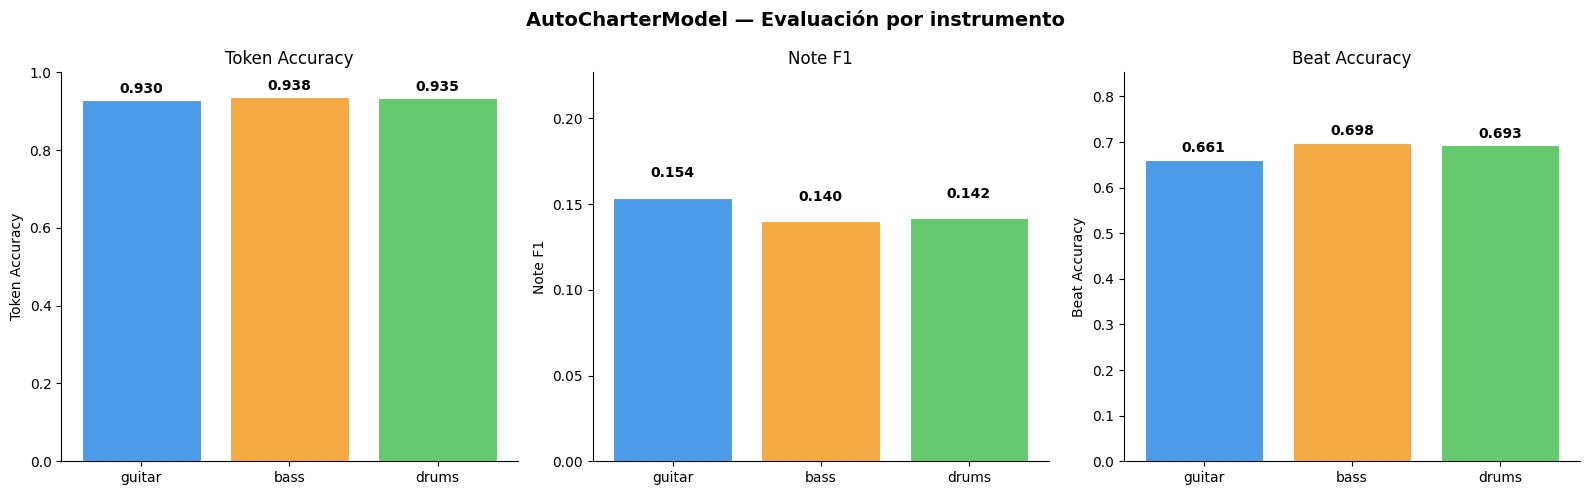

Figura guardada: eval_by_instrument.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("AutoCharterModel — Evaluación por instrumento", fontsize=14, fontweight="bold")

_COLORS = {"guitar": "#4C9BE8", "bass": "#F4A942", "drums": "#65C96E"}
instrs  = [k for k in ("guitar", "bass", "drums") if k in global_acc]

metrics_to_plot = [
    ("tok_acc",  "Token Accuracy",  0, 1),
    ("note_f1",  "Note F1",         0, 1),
    ("beat_acc", "Beat Accuracy",   0, 1),
]

for ax, (metric_key, metric_label, ymin, ymax) in zip(axes, metrics_to_plot):
    values = [avg(global_acc[k], metric_key) for k in instrs]
    colors = [_COLORS[k] for k in instrs]
    bars = ax.bar(instrs, values, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(metric_label, fontsize=12)
    ax.set_ylim(ymin, min(ymax, max(values) * 1.15 + 0.05))
    ax.set_ylabel(metric_label)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold"
        )
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("eval_by_instrument.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: eval_by_instrument.png")

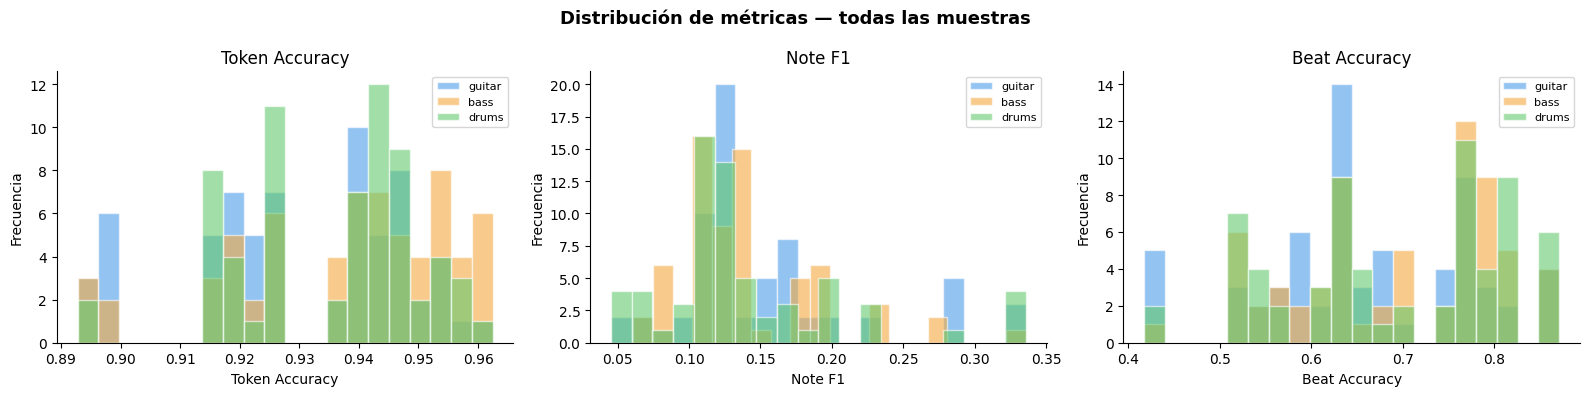

Figura guardada: eval_distributions.png


In [9]:
# ── Distribución de métricas por muestra ─────────────────────────────────────
import pandas as pd

df = pd.DataFrame(all_results)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Distribución de métricas — todas las muestras", fontsize=13, fontweight="bold")

for ax, (col, label) in zip(axes, [("tok_acc", "Token Accuracy"),
                                    ("note_f1", "Note F1"),
                                    ("beat_accuracy", "Beat Accuracy")]):
    for instr, color in _COLORS.items():
        sub = df[df["instrument"] == instr][col]
        if len(sub):
            ax.hist(sub, bins=20, alpha=0.6, color=color, label=instr, edgecolor="white")
    ax.set_xlabel(label)
    ax.set_ylabel("Frecuencia")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("eval_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: eval_distributions.png")

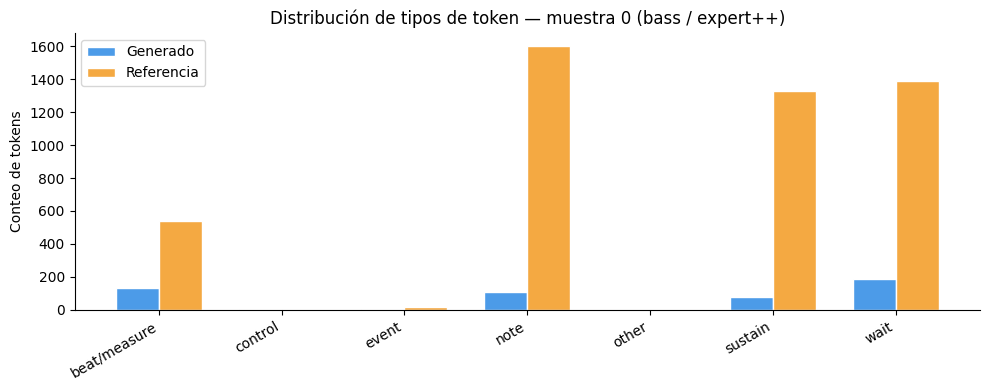

Figura guardada: inference_token_dist.png


In [10]:
# ── Comparación tokens generados vs. referencia (muestra de inferencia) ───────
from auto_charter.vocab.tokens import Vocab

def token_type(t: int) -> str:
    if t == Vocab.PAD:            return "PAD"
    if t == Vocab.BOS:            return "BOS"
    if t == Vocab.EOS:            return "EOS"
    if t == Vocab.BEAT_BOUNDARY:  return "BEAT"
    if t == Vocab.MEASURE_START:  return "MEAS"
    if Vocab.WAIT_START <= t <= Vocab.WAIT_END:
        return f"WAIT{t - Vocab.WAIT_START + 1}"
    if Vocab.GUITAR_NOTE_START <= t <= Vocab.GUITAR_NOTE_END:
        return f"GN{t - Vocab.GUITAR_NOTE_START + 1}"
    if Vocab.DRUM_NOTE_START <= t <= Vocab.DRUM_NOTE_END:
        return f"DN{t - Vocab.DRUM_NOTE_START + 1}"
    if Vocab.SUS_START <= t <= Vocab.SUS_END:
        return f"SUS{t - Vocab.SUS_START}"
    if t == Vocab.MOD_HOPO:       return "HOPO"
    if t == Vocab.MOD_TAP:        return "TAP"
    return f"T{t}"

def type_histogram(tokens: list[int]) -> dict[str, int]:
    counts: dict[str, int] = defaultdict(int)
    for t in tokens:
        if   t == Vocab.BOS or t == Vocab.EOS or t == Vocab.PAD:
            counts["control"] += 1
        elif t == Vocab.BEAT_BOUNDARY or t == Vocab.MEASURE_START:
            counts["beat/measure"] += 1
        elif Vocab.WAIT_START <= t <= Vocab.WAIT_END:
            counts["wait"] += 1
        elif Vocab.GUITAR_NOTE_START <= t <= Vocab.DRUM_NOTE_END:
            counts["note"] += 1
        elif Vocab.SUS_START <= t <= Vocab.SUS_END:
            counts["sustain"] += 1
        elif t in (Vocab.MOD_HOPO, Vocab.MOD_TAP, Vocab.MOD_OPEN, Vocab.MOD_FORCE_STRUM):
            counts["modifier"] += 1
        elif t in (Vocab.STAR_POWER_ON, Vocab.STAR_POWER_OFF, Vocab.SOLO_ON, Vocab.SOLO_OFF):
            counts["event"] += 1
        else:
            counts["other"] += 1
    return dict(counts)

gen_hist = type_histogram(generated_tokens)
ref_hist = type_histogram(ref_tokens)

categories = sorted(set(gen_hist) | set(ref_hist))
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width/2, [gen_hist.get(c, 0) for c in categories], width,
       label="Generado", color="#4C9BE8", edgecolor="white")
ax.bar(x + width/2, [ref_hist.get(c, 0) for c in categories], width,
       label="Referencia", color="#F4A942", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=30, ha="right")
ax.set_ylabel("Conteo de tokens")
ax.set_title(f"Distribución de tipos de token — muestra {SAMPLE_IDX} "
             f"({_INSTR_NAMES.get(instr_id)} / {_DIFF_NAMES.get(diff_id)})")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("inference_token_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: inference_token_dist.png")